In [46]:
import pandas as pd     # untuk membuat dan mengolah DataFrame
import numpy as np      # untuk operasi matematika (sqrt, array, dll)
import matplotlib.pyplot as plt   # untuk membuat grafik/visualisasi
from sklearn.linear_model import LinearRegression   # model regresi linear
from sklearn.model_selection import train_test_split    # membagi data train & test
from sklearn import metrics   # untuk evaluasi model (MAE, MSE, RMSE)

In [47]:
# Dataset
import pandas as pd
data = {
    'biaya_iklan': [1,2,3,4,5,6,7,8,9,10,11,12,13,14],             # juta rupiah
    'penjualan':   [50,54,58,62,66,70,74,78,82,86,90,95,100,100]   # unit terjual (ratusan)
}

# Mengubah dictionary menjadi DataFrame agar mudah diolah
df = pd.DataFrame(data)
print(df)   # Menampilkan seluruh data dalam bentuk tabel

    biaya_iklan  penjualan
0             1         50
1             2         54
2             3         58
3             4         62
4             5         66
5             6         70
6             7         74
7             8         78
8             9         82
9            10         86
10           11         90
11           12         95
12           13        100
13           14        100


In [48]:
# Menentukan variabel
x = df[['biaya_iklan']]
y = df[['penjualan']]

In [49]:
# Split data train dan test
# Test_size=0.2 : 20% data untuk testing, 80% untuk training
# Random_state=42 : agar hasil pembagian data selalu sama setiap dijalankan
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [50]:
# Membuat model regresi
model = LinearRegression()
model.fit(x_train, y_train)    # Model menggunakan data training

LinearRegression()

In [51]:
# Melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_)   # nilai a: titik potong garis di sumbu Y
print("koefisien (b):", model.coef_[0])     # nilai b: kemiringan garis

Intercept (a): [46.09392898]
koefisien (b): [3.98739977]


In [52]:
# Prediksi data testing
y_pred = model.predict(x_test)

print("Data Testing:")
print(x_test)         # Menampilkan nilai biaya iklan yang diuji
print("Penjualan Asli:", y_test.values)
print("Penjualan Prediksi:", y_pred)

Data Testing:
    biaya_iklan
9            10
11           12
0             1
Penjualan Asli: [[86]
 [95]
 [50]]
Penjualan Prediksi: [[85.96792669]
 [93.94272623]
 [50.08132875]]


In [53]:
# Evaluasi
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))            # MAE: rata-rata selisih absolut antara nilai asli dan prediksi (semakin kecil semakin baik)
print("MSE:", metrics.mean_squared_error(y_test, y_pred))             # MSE: rata-rata kuadrat selisih (lebih sensitif terhadap error besar)
print ("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))  # RMSE: akar dari MSE, satuannya sama dengan data asli (ratusan unit)

MAE: 0.39022527682321595
MSE: 0.3751569616167389
RMSE: 0.6125005809113481


In [55]:
# Prediksi
prediksi = model.predict([[15]])
print("Prediksi Penjualan untuk biaya iklan 15 juta", prediksi[0])

Prediksi Penjualan untuk biaya iklan 15 juta [105.90492554]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


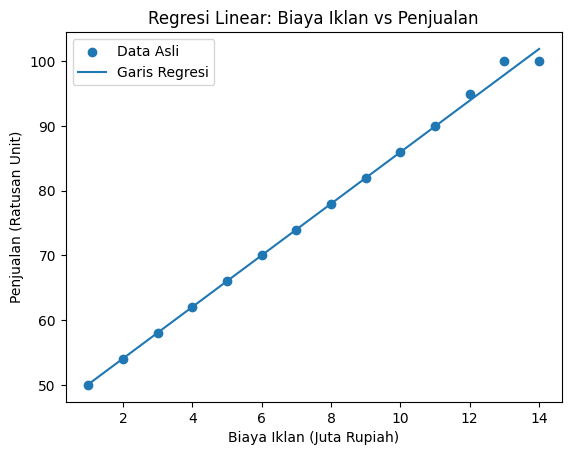

In [56]:
plt.scatter(x,y, label="Data Asli")
plt.plot(x, model.predict(x), label="Garis Regresi")
plt.xlabel("Biaya Iklan (Juta Rupiah)")
plt.ylabel("Penjualan (Ratusan Unit)")
plt.title("Regresi Linear: Biaya Iklan vs Penjualan")
plt.legend()  # Menampilkan keterangan garis/titiK
plt.show()    # Menampilkan grafik